# Deutsch-Jozsa Quantum Algorithm
This notebook demonstrates quantum speedup. The algorithm identifies whether a hidden function is **constant** or **balanced** in just **one** query ($O(1)$), whereas a classical computer would need $O(2^{n-1}+1)$ queries.

### Imports
We use `qiskit` for circuit building and `qiskit_aer` for local simulation.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## 1. The Oracle (Black Box)
The Oracle $U_f$ encodes the function $f(x)$. 
- If **constant**, it does nothing or flips the output.
- If **balanced**, it uses CNOT gates to create dependence on input.

In [2]:
def build_dj_oracle(n, f_type='constant'):
    qc = QuantumCircuit(n + 1, name="Uf")
    if f_type == 'balanced':
        for i in range(n):
            qc.cx(i, n)
    elif f_type == 'constant':
        # Example: f(x) = 1
        qc.x(n)
    return qc

## 2. The Main Circuit
We prepare input qubits in superposition $|+\rangle$ and the ancilla qubit in $|-\rangle$. After the Oracle call, we apply Hadamard gates to cause interference.

In [3]:
def deutsch_jozsa_circuit(n, f_type='constant'):
    qc = QuantumCircuit(n + 1, n, name="DJ")
    
    # Initialize ancilla to |->
    qc.x(n)
    qc.h(n)
    
    # Put input qubits in superposition
    for i in range(n):
        qc.h(i)
        
    # Apply Oracle
    Uf = build_dj_oracle(n, f_type=f_type)
    qc.append(Uf.to_gate(), list(range(n + 1)))
    
    # Apply Hadamards again
    for i in range(n):
        qc.h(i)
        
    # Measure
    for i in range(n):
        qc.measure(i, i)
        
    return qc

## 3. Execution
We run the simulation for both **Constant** and **Balanced** cases. 
- Result `000` means **Constant**.
- Any other result means **Balanced**.

In [4]:
n = 3
simulator = AerSimulator()

# Run Constant Case
qc_c = deutsch_jozsa_circuit(n, 'constant')
counts_c = simulator.run(transpile(qc_c, simulator)).result().get_counts()

# Run Balanced Case
qc_b = deutsch_jozsa_circuit(n, 'balanced')
counts_b = simulator.run(transpile(qc_b, simulator)).result().get_counts()

print(f"Constant Case Counts: {counts_c}")
print(f"Balanced Case Counts: {counts_b}")

Constant Case Counts: {'000': 1024}
Balanced Case Counts: {'111': 1024}


## 4. Final Visualization
Visual comparison of the measurement probabilities.

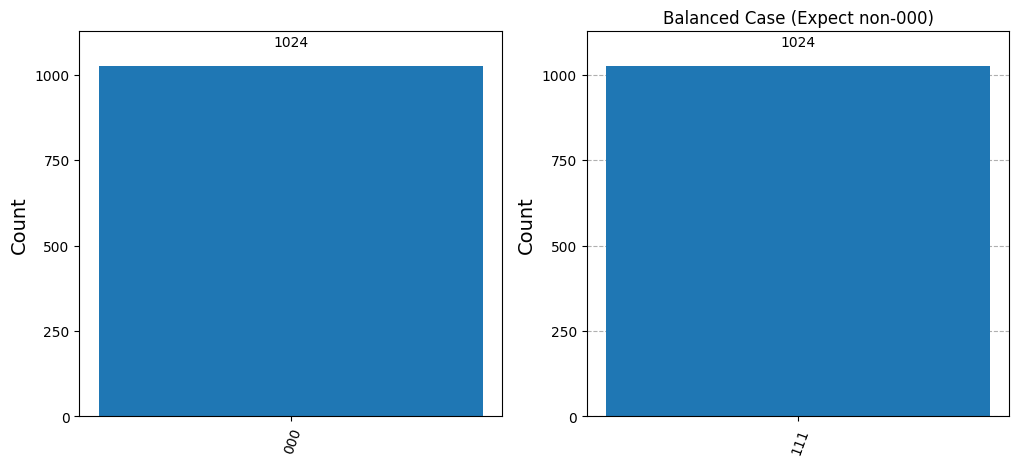

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_histogram(counts_c, ax=ax1, title='Constant Case (Expect 000)')
plot_histogram(counts_b, ax=ax2, title='Balanced Case (Expect non-000)')
plt.show()